<a href="https://colab.research.google.com/github/rabianaz001/19th-august-assignment/blob/main/Feed_Forward_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
 import tensorflow as tf
 from tensorflow import keras
 from tensorflow.keras import Sequential

In [4]:
model = Sequential()
model.add(tf.keras.layers.Dense(32,input_shape =(x_train.shape[1]),activation ='relu'))
model.add(tf.keras.layers.Dense(1))

NameError: name 'x_train' is not defined

In [5]:
import seaborn as sns
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [6]:
df = sns.load_dataset('mpg')
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

In [7]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
df.shape

(398, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [12]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [11]:
df['horsepower'].fillna(df['horsepower'].mean(), inplace = True)

In [13]:
df = df.drop('name', axis = 1)

In [14]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin'],
      dtype='object')

In [16]:
print(df['horsepower'].skew())
print(df['displacement'].skew())
print(df['weight'].skew())
print(df['acceleration'].skew())


1.0955524807071189
0.7196451643005952
0.5310625125994629
0.27877684462588986


skew ()= if the value is between 1 and -1 we don't have any outliers

In [19]:
import numpy as np
df['hprsepower'] = np.where(df['horsepower']>200,200 ,df['horsepower'])

<Axes: ylabel='horsepower'>

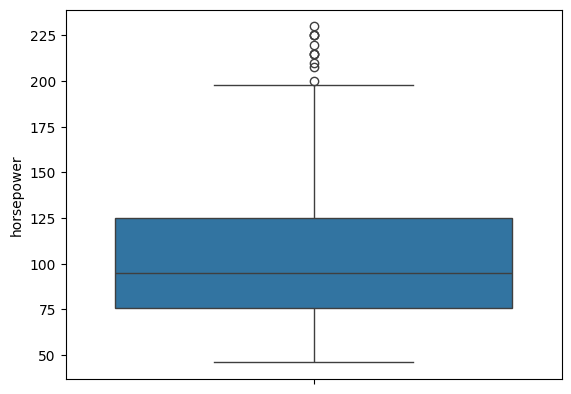

In [20]:
sns.boxplot(df['horsepower'])

DUMMY ENCODING

In [21]:
import pandas as pd
df = pd.get_dummies(df, columns = ['origin'],drop_first = True ,prefix = 'origin ',dtype=int)

In [22]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,hprsepower,origin _japan,origin _usa
0,18.0,8,307.0,130.0,3504,12.0,70,130.0,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,165.0,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,150.0,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,150.0,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,140.0,0,1


In [23]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,hprsepower,origin _japan,origin _usa
393,27.0,4,140.0,86.0,2790,15.6,82,86.0,0,1
394,44.0,4,97.0,52.0,2130,24.6,82,52.0,0,0
395,32.0,4,135.0,84.0,2295,11.6,82,84.0,0,1
396,28.0,4,120.0,79.0,2625,18.6,82,79.0,0,1
397,31.0,4,119.0,82.0,2720,19.4,82,82.0,0,1


mpg is linear dataset
cylinder and model_year , though have datatype of int but they define car category, so we need to perform one_hot encoding
e.g - 1970 and 2024 is category model

In [24]:
df = pd.get_dummies(df, columns = ['cylinders'],drop_first = True ,prefix = 'cylinder ',dtype=int)
df = pd.get_dummies(df, columns = ['model_year'],drop_first = True ,prefix = 'year',dtype=int)

In [25]:
df.columns

Index(['mpg', 'displacement', 'horsepower', 'weight', 'acceleration',
       'hprsepower', 'origin _japan', 'origin _usa', 'cylinder _4',
       'cylinder _5', 'cylinder _6', 'cylinder _8', 'year_71', 'year_72',
       'year_73', 'year_74', 'year_75', 'year_76', 'year_77', 'year_78',
       'year_79', 'year_80', 'year_81', 'year_82'],
      dtype='object')

In [27]:
target = ['mpg']
predictors = list(set(list(df.columns))-set(target))

In [28]:
predictors

['year_72',
 'cylinder _4',
 'cylinder _6',
 'weight',
 'year_73',
 'year_78',
 'year_79',
 'year_80',
 'origin _japan',
 'year_82',
 'cylinder _8',
 'origin _usa',
 'hprsepower',
 'year_71',
 'acceleration',
 'horsepower',
 'year_81',
 'year_76',
 'cylinder _5',
 'year_74',
 'displacement',
 'year_75',
 'year_77']

In [29]:
x = df[predictors].values
y = df[target].values

In [30]:
type(x)

numpy.ndarray

In [31]:
x

array([[  0.,   0.,   0., ..., 307.,   0.,   0.],
       [  0.,   0.,   0., ..., 350.,   0.,   0.],
       [  0.,   0.,   0., ..., 318.,   0.,   0.],
       ...,
       [  0.,   1.,   0., ..., 135.,   0.,   0.],
       [  0.,   1.,   0., ..., 120.,   0.,   0.],
       [  0.,   1.,   0., ..., 119.,   0.,   0.]])

In [32]:
y

array([[18. ],
       [15. ],
       [18. ],
       [16. ],
       [17. ],
       [15. ],
       [14. ],
       [14. ],
       [14. ],
       [15. ],
       [15. ],
       [14. ],
       [15. ],
       [14. ],
       [24. ],
       [22. ],
       [18. ],
       [21. ],
       [27. ],
       [26. ],
       [25. ],
       [24. ],
       [25. ],
       [26. ],
       [21. ],
       [10. ],
       [10. ],
       [11. ],
       [ 9. ],
       [27. ],
       [28. ],
       [25. ],
       [25. ],
       [19. ],
       [16. ],
       [17. ],
       [19. ],
       [18. ],
       [14. ],
       [14. ],
       [14. ],
       [14. ],
       [12. ],
       [13. ],
       [13. ],
       [18. ],
       [22. ],
       [19. ],
       [18. ],
       [23. ],
       [28. ],
       [30. ],
       [30. ],
       [31. ],
       [35. ],
       [27. ],
       [26. ],
       [24. ],
       [25. ],
       [23. ],
       [20. ],
       [21. ],
       [13. ],
       [14. ],
       [15. ],
       [14. ],
       [17

In [34]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3, random_state= 1)

In [38]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

In [40]:
x_train.dtype

dtype('float32')

BUILD NEURAL NETWORK

In [50]:
model = Sequential()
model.add(tf.keras.layers.Dense(32,input_shape =(x_train.shape[1],),activation ='relu'))
model.add(tf.keras.layers.Dense(1))

In [51]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 32)                768       
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 801 (3.13 KB)
Trainable params: 801 (3.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
